# Dataset Preparation

- input: curated briefsummary
- output: pd.series of ase objects pr pymatgen objects


In [2]:
from Tools.DatasetTools.Commoms import *
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer import Featurizer
from Tools.DatasetTools.Tools import need_to_update
from Tools.DatasetTools.SublatticeSorter import *
from pymatgen.io.ase import AseAtomsAdaptor

# options 

In [3]:
dataset = 'Fe-Mo'#'Cr-Co-W'
case='POSCAR-initial' #, 'POSCAR-relaxed']
rescale_by_atoms=True #, False]
subcase = 'rescaled' # ,  'noscaled' ] 
Force= True
CuratedBS = os.path.join(dataset,'FurtherCuratedParsedBriefSummary.pkl')

In [4]:
components = dataset.replace('-','')

In [5]:
BS = pd.read_pickle(CuratedBS)

Features = Featurizer(BS)

chech that the chemistry resetting is correct!

# Sort Poscar files

In [6]:
searchs = 'POSCAR.initial'
files = get_file_paths(dataset, searchs)
atomsobjectslocation = os.path.join(dataset,'Atomsobjects')
sublatticesortersfile = os.path.join(atomsobjectslocation, 'SORTERS.pkl')
sublatticetagfile = os.path.join(atomsobjectslocation, 'SUBLATICETAGS.pkl')

In [7]:
#if need_to_update(sublatticesortersfile) or need_to_update(sublatticetagfile):
#    SORTERS, SUBLATICETAGS = get_all_sorters_and_tags(dataset, files)
#    SORTERS.to_pickle(sublatticesortersfile)
#    SUBLATICETAGS.to_pickle(sublatticetagfile)
#else:
SORTERS = pd.read_pickle(sublatticesortersfile)
SUBLATICETAGS = pd.read_pickle(sublatticetagfile)

# Now I have to pick the atoms objects

In [8]:
#for thiscase, (thisrescale, thissubcase) in product(case, zip(rescale_by_atoms, subcase)):
database = f'{dataset}/**/{case}'
AtomsFile = os.path.join(atomsobjectslocation,f'{components}-{case}-{subcase}-AtomsObjects.pkl')

In [9]:
if not need_to_update(AtomsFile):  #os.path.exists(AtomsFile) and not Force:
    Atoms_Objects = pd.read_pickle(AtomsFile)
else:
    Atoms_Objects, CantMake_Atoms_Object = Features.get_atoms_object(database=database,rescale_by_atoms=True, reset_chemistry=True,file_filter = 'initial$')
    Atoms_Objects.to_pickle(AtomsFile)
    Atoms_Objects.dropna(inplace=True)
pymatgenfile = AtomsFile.replace('AtomsObjects','PymatgenStructures')
Pymatgen_Structures = Atoms_Objects.copy()
if not need_to_update(pymatgenfile):
    Pymatgen_Structures = pd.read_pickle(pymatgenfile)
else:
    Pymatgen_Structures = Atoms_Objects['atoms'].apply(AseAtomsAdaptor.get_structure)
    Pymatgen_Structures['file'] = Atoms_Objects['file']
    Pymatgen_Structures.to_pickle(pymatgenfile)

  0%|          | 0/274 [00:00<?, ?it/s]

In [10]:
Atoms_Objects.atoms.isna().sum()

0

In [11]:
Atoms_Objects.to_pickle(AtomsFile)

In [12]:
accomodatewrap = Atoms_Objects.atoms.map(lambda a: a.wrap(pretty_translation=True))

In [13]:
difference = BS.index.difference(Atoms_Objects.index)

In [14]:
difference

Index([], dtype='object', name='index')

#  visualization of some structures

In [15]:
plt.rc('axes.spines', bottom=False, top=False, right=False, left=False)

In [16]:
from ase.visualize.plot import plot_atoms

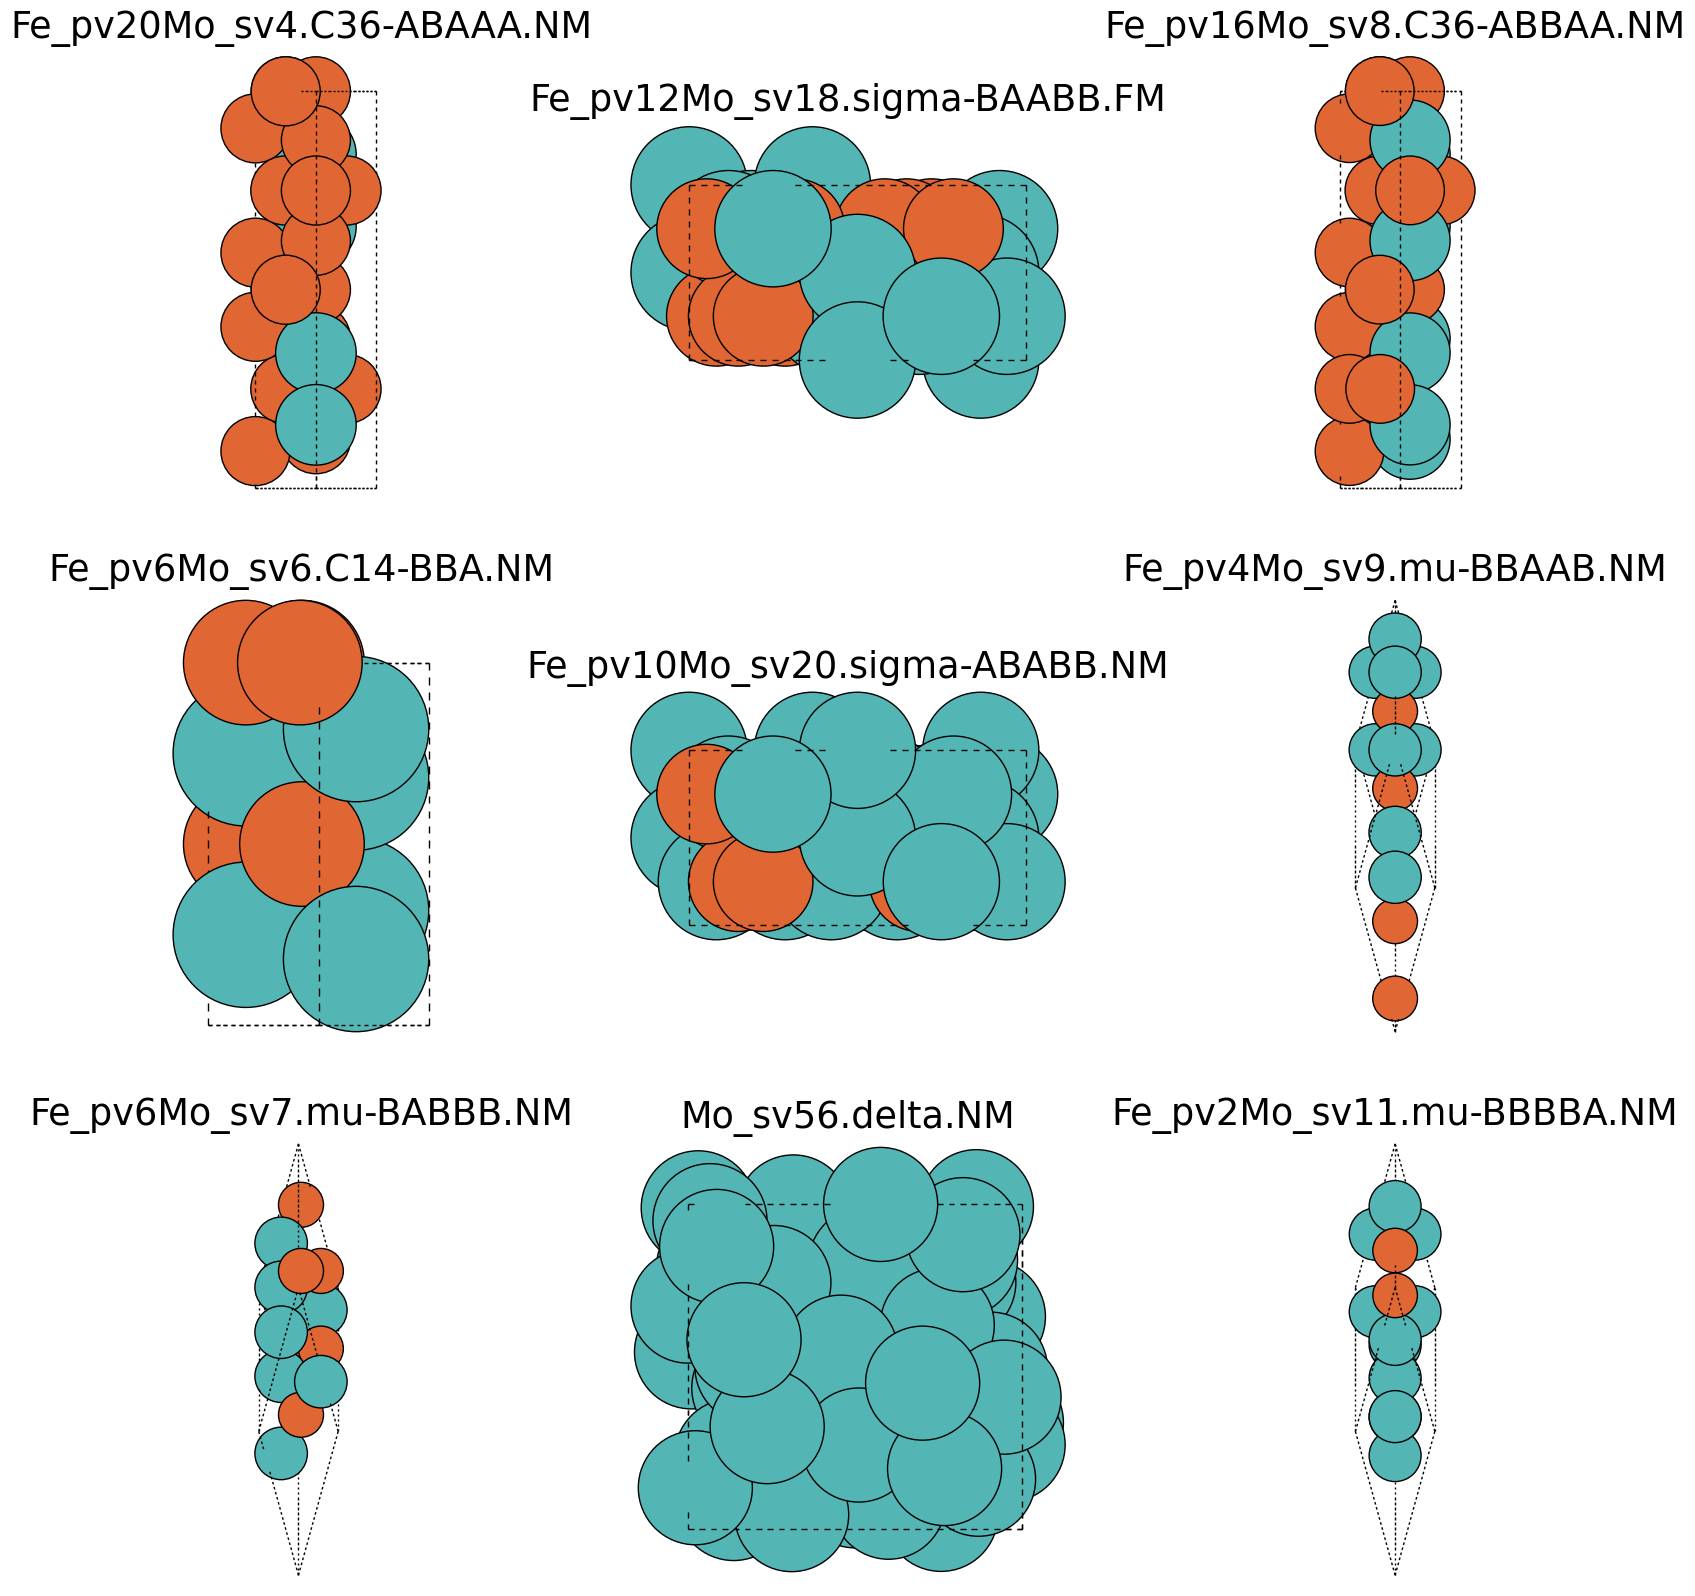

In [17]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, atoms_samples.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation = '90x')
#    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

In [18]:
somesigmas = Atoms_Objects.atoms[Atoms_Objects.index.str.contains('sigma')].sample(n=9)

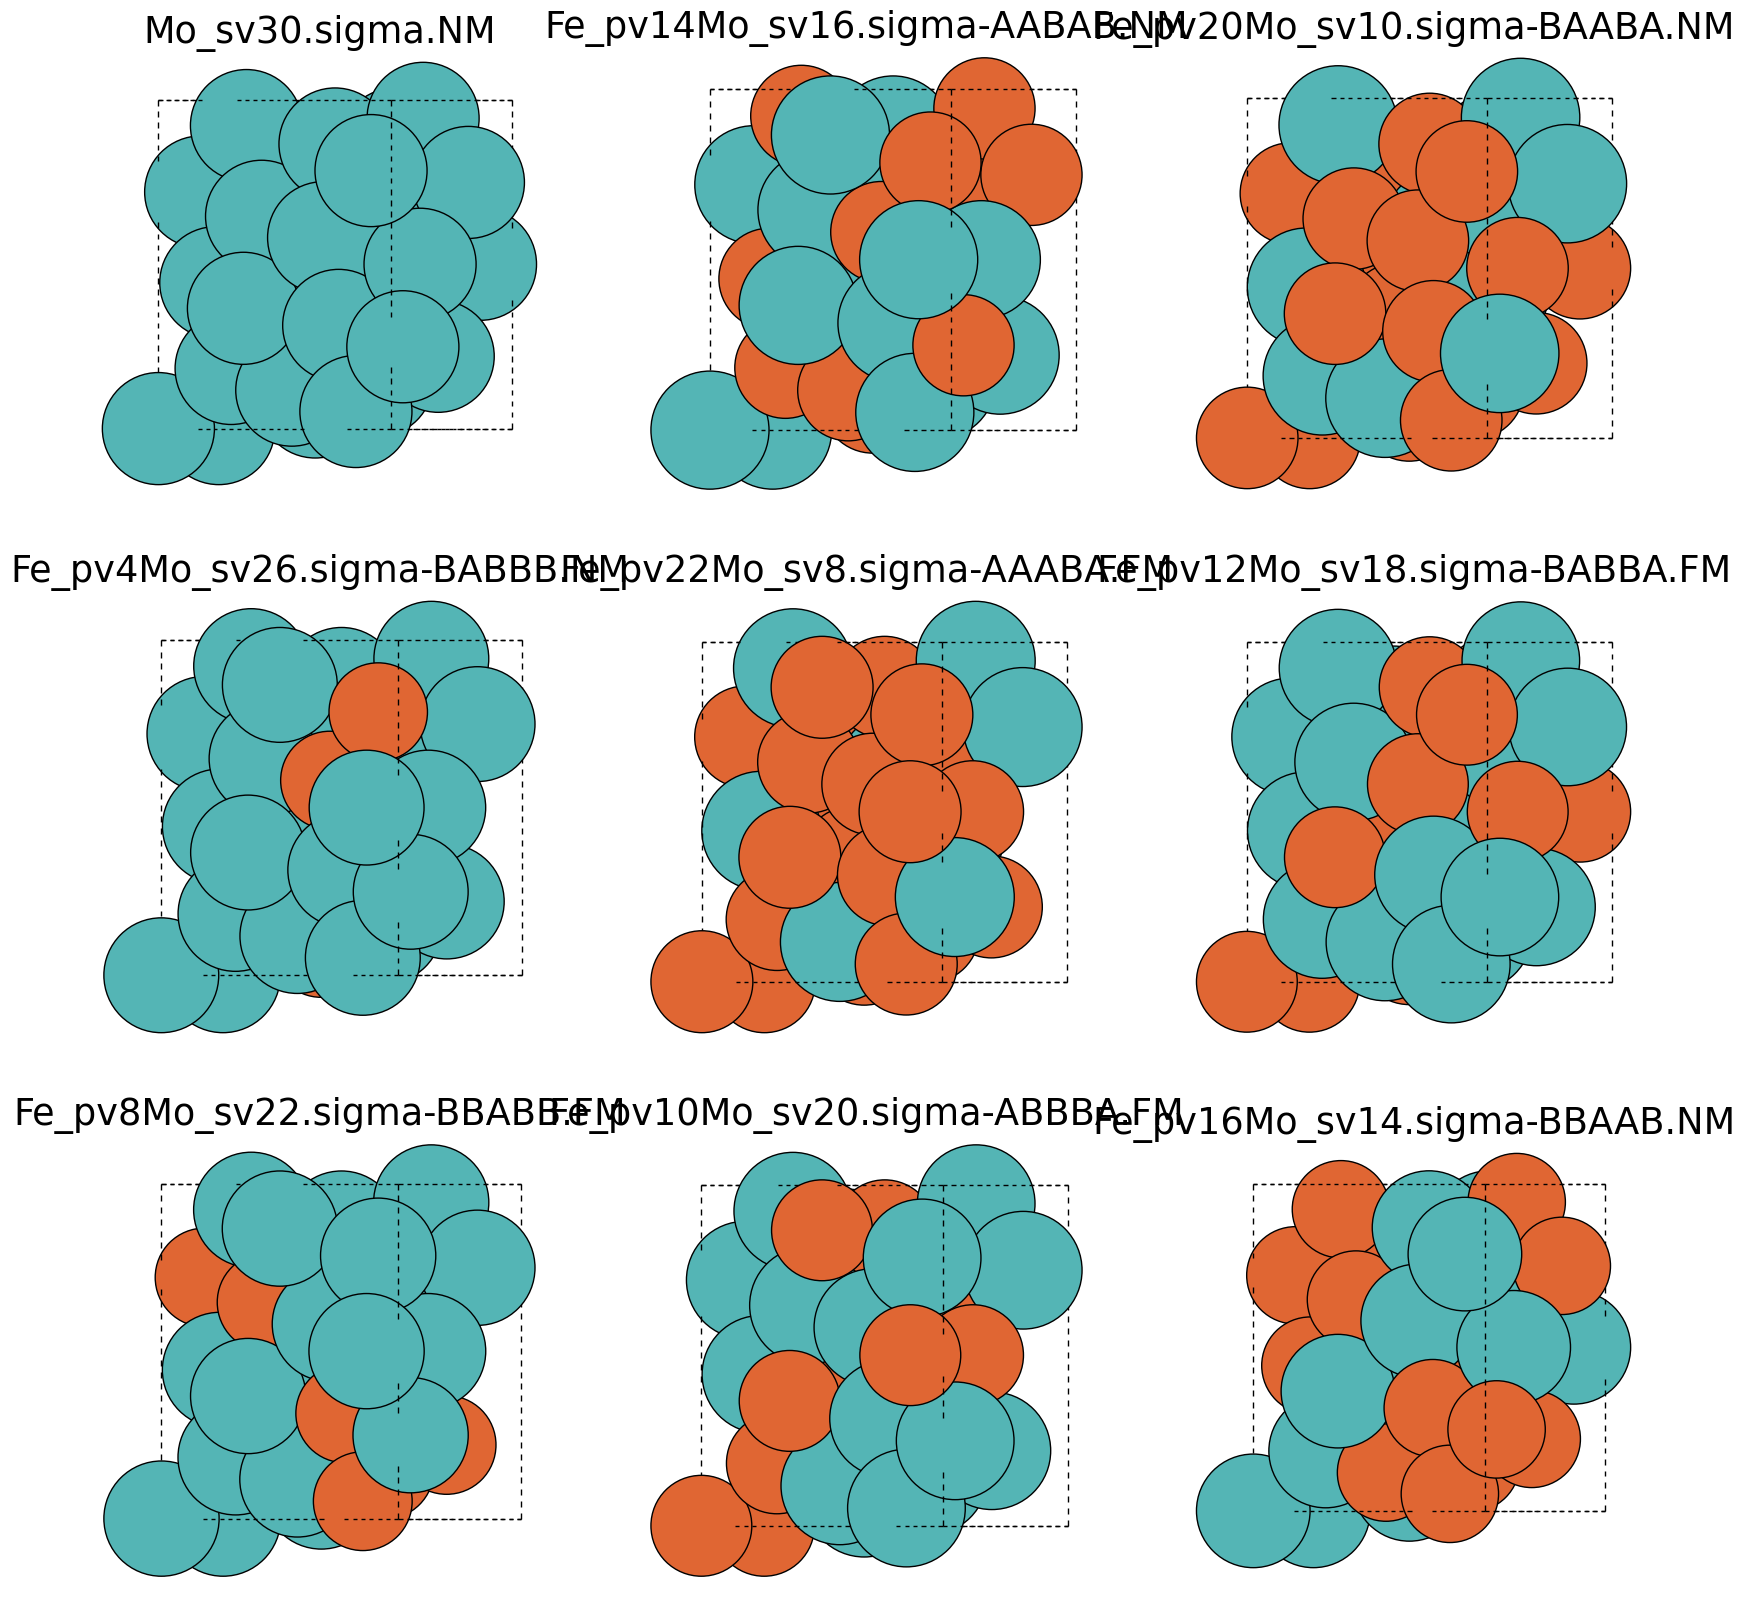

In [19]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, somesigmas.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation='90y, 90x, 45y')
    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

 For the actual visualization of the structures, we should choose one example for each structure and then draw in Vesta or Ovito for good quality figures, including coordination polyhedra etc.

# Curate Dataset to available structures 

There are still some R structures not available in data but present in briefsummaries

In [20]:
Problems = BS.index.difference(Atoms_Objects.index)

In [21]:
BS.loc[Problems]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Fe_pv,Mo_sv,EF,Phase
index,,,,,,,,,,,,,,,,,,,,,


In [22]:
GoodBS = BS.loc[Atoms_Objects.index]

In [23]:
GoodBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Fe_pv,Mo_sv,EF,Phase
index,,,,,,,,,,,,,,,,,,,,,
Fe_pv24.C36.FM,bulk C36.FM,12.049606 A,-8.109714,150.452690 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,,24,0,0,24.0,1.000000,0.000000,0.14558,C36
Fe_pv29.chi.FM,bulk chi.FM,12.050793 A,-8.137048,152.259441 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,,29,0,0,29.0,1.000000,0.000000,0.118246,chi
Fe_pv14Mo_sv10.C36-AABAB.FM,bulk C36-AABAB.FM,14.643681 A,-8.883492,154.045319 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,14,10,0,24.0,0.583333,0.416667,0.488047,C36
Fe_pv22Mo_sv8.sigma-AAAAB.FM,bulk sigma-AAAAB.FM,12.759638 A,-8.843901,158.862435 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,22,8,0,30.0,0.733333,0.266667,0.12579,sigma
Fe_pv14Mo_sv10.C36-ABAAB.FM,bulk C36-ABAAB.FM,13.931013 A,-9.081825,159.466599 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,14,10,0,24.0,0.583333,0.416667,0.289714,C36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv25Mo_sv4.chi-ABAA.NM,bulk chi-ABAA,11.072302 A,-8.505552,279.868523 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,25,4,0,29.0,0.862069,0.137931,0.119258,chi
Fe_pv16Mo_sv8.C36-BBAAA.NM,bulk C36-BBAAA,12.044661 A,-9.117739,281.820517 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,16,8,0,24.0,0.666667,0.333333,0.030551,C36
Fe_pv8Mo_sv4.C14-BAA.NM,bulk C14-BAA,12.031891 A,-9.133101,282.397960 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,8,4,0,12.0,0.666667,0.333333,0.015189,C14


In [24]:
FullyCuratedBSFile = os.path.join(dataset,'FullyCuratedParsedBriefSummary.pkl')

In [25]:
GoodBS.to_pickle(FullyCuratedBSFile)

#  Final Distributions of targets

In [26]:
plt.rc('axes.spines', bottom=True, top=True, right=True, left=True)

<AxesSubplot:xlabel='B0', ylabel='Count'>

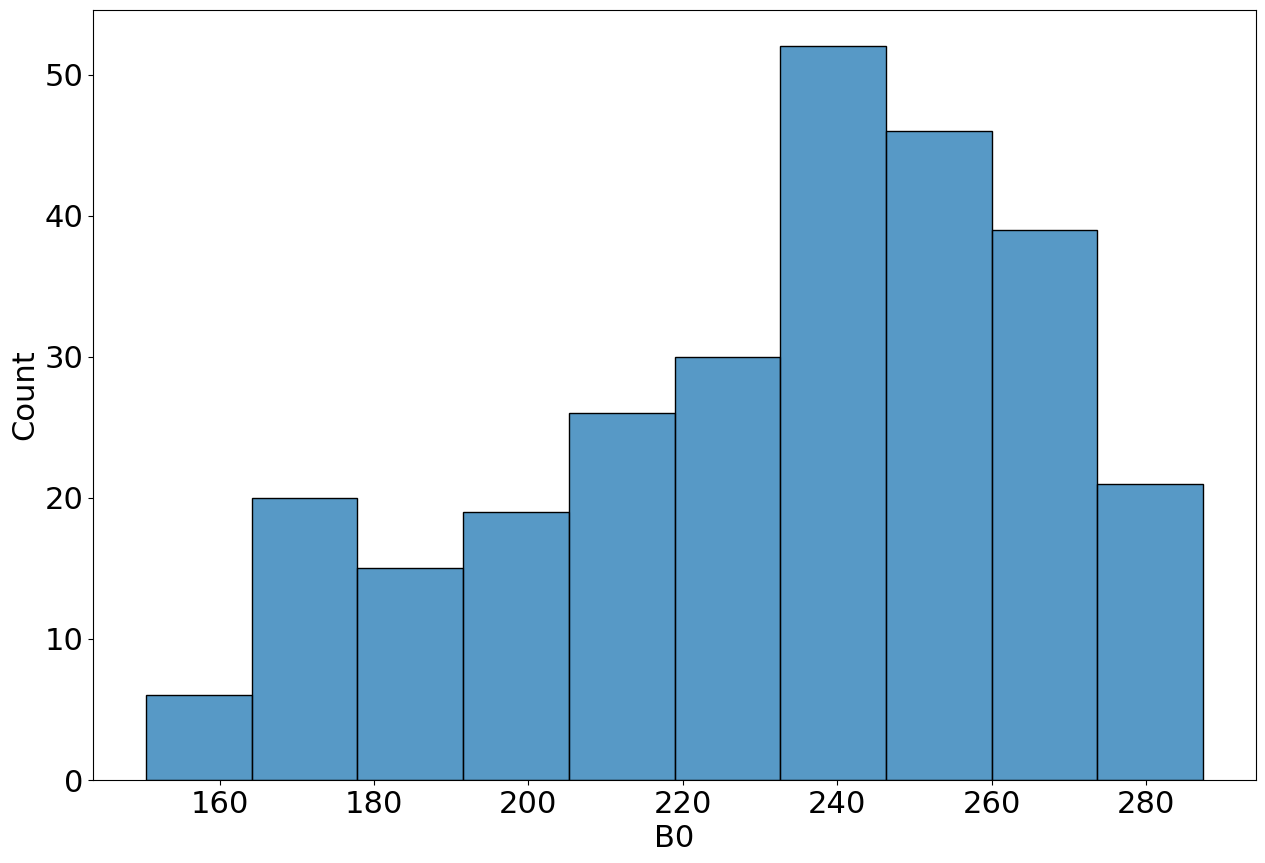

In [27]:
sns.histplot(BS['B0'])

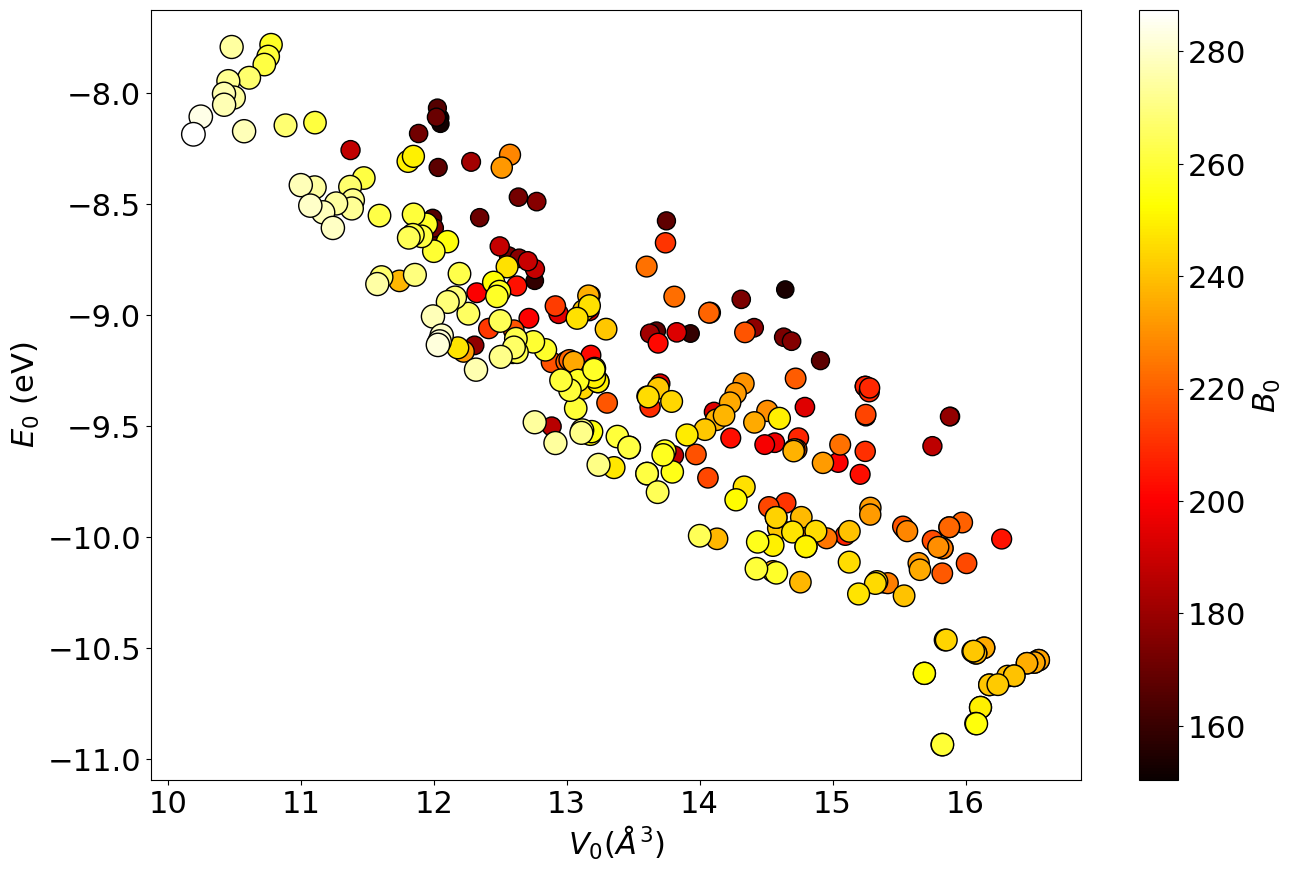

In [29]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.E0, c=BS.B0, marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(r'$E_0$ (eV)')
plt.xlabel(r'$V_0 (\AA^3)$')
cbar.set_label(r'$B_0$')
#outlier_left =BS[(BS['E0']<-10) & (BS['V0']<11)].index
#plt.annotate(outlier_left[0],*BS.loc[outlier_left][['V0', 'E0']].values, fontsize=16 )